# Customer Churn Prediction using Decision Tree

This project uses a Decision Tree Classifier to predict whether a customer will churn based on customer and service-related features.

The project covers data cleaning, preprocessing, train/test splitting, model training, evaluation, and visualization of the model results.


## Import Libraries
In this section, we import the required libraries for data manipulation, machine learning, model evaluation, and data visualization.

In [205]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

## 1. Data Loading

In this section, the customer churn dataset is loaded using pandas and the first rows are displayed to get an initial understanding of the data.


In [206]:
df = pd.read_csv('customer_churn.csv' , delimiter = ',')
df.head(10)

,Age,Tenure,MonthlyCharges,SupportCalls,ContractType,InternetService,PaymentMethod,Churn
0,56,16,38.19,4,Yearly,Fiber,Bank Transfer,No
1,69,39,54.57,2,Yearly,DSL,Credit Card,No
2,46,5,109.68,1,Yearly,Fiber,Credit Card,Yes
3,32,22,67.40,8,Yearly,DSL,Bank Transfer,Yes
4,60,29,86.76,8,Yearly,DSL,Credit Card,Yes
5,25,55,37.23,0,Monthly,NaN,Credit Card,No
6,38,3,39.23,2,Monthly,Fiber,Electronic Check,No
7,56,12,24.09,7,Two-Year,Fiber,Electronic Check,Yes
8,36,26,36.89,5,Yearly,DSL,Bank Transfer,No
9,40,16,47.86,4,Yearly,Fiber,Bank Transfer,Yes


## 2. Data Cleaning

First, missing values are identified using `isna().sum()`.

Rows containing missing values are then removed from the dataset using `dropna()` so that the data can be used for model training.


In [230]:
df.isna().sum()
df = df.dropna()

## 3. Feature Selection

The input features are separated from the target variable.

The selected features include customer age, tenure, monthly charges, support calls, contract type, internet service, and payment method.


In [231]:
X = df[['Age' , 'Tenure' , 'MonthlyCharges' , 'SupportCalls' , 'ContractType' , 'InternetService' , 'PaymentMethod']].values
X[0:5]

array([[56, 16, 38.19, 4, 'Yearly', 'Fiber', 'Bank Transfer'],
       [69, 39, 54.57, 2, 'Yearly', 'DSL', 'Credit Card'],
       [46, 5, 109.68, 1, 'Yearly', 'Fiber', 'Credit Card'],
       [32, 22, 67.4, 8, 'Yearly', 'DSL', 'Bank Transfer'],
       [60, 29, 86.76, 8, 'Yearly', 'DSL', 'Credit Card']], dtype=object)

## 4. Categorical Feature Encoding

The categorical features contain text values, so they need to be converted into numerical values before training the Decision Tree model.

`LabelEncoder` is used to transform the categorical feature values into numerical representations.


In [232]:
from sklearn import preprocessing
le_ct = preprocessing.LabelEncoder()
le_ct.fit(['Yearly' , 'Monthly' , 'Two_Year'])
X[:,4] = le_ct.fit_transform(X[:,4])

le_is = preprocessing.LabelEncoder()
le_is.fit(['Fiber' , 'DSL'])
X[:,5] = le_is.fit_transform(X[:,5])

le_pm = preprocessing.LabelEncoder()
le_pm.fit(['Bank Transfer' , 'Credit Card' , 'Electronic Check'])
X[:,6] = le_pm.fit_transform(X[:,6])

X[0:5]

array([[56, 16, 38.19, 4, 2, 1, 0],
       [69, 39, 54.57, 2, 2, 0, 1],
       [46, 5, 109.68, 1, 2, 1, 1],
       [32, 22, 67.4, 8, 2, 0, 0],
       [60, 29, 86.76, 8, 2, 0, 1]], dtype=object)

## 5. Target Variable

The target variable is `Churn`, which indicates whether a customer has left the service.

* `No` → Customer did not churn
* `Yes` → Customer churned


In [235]:
y = df[['Churn']].values
y[0:5]

array([['No'],
       ['No'],
       ['Yes'],
       ['Yes'],
       ['Yes']], dtype=object)

## Optional job

In [211]:
# le_churn = preprocessing.LabelEncoder()
# y = le_churn.fit_transform(df['Churn'])

# y[0:10]

## 6. Train/Test Split

The dataset is divided into training and testing sets.

70% of the data is used for training the model, while 30% is reserved for testing its performance on unseen data.


In [212]:
from sklearn.model_selection import train_test_split

In [213]:
x_train , x_test , y_train , y_test = train_test_split(X , y , test_size = 0.3 , random_state = 3)
print('Shape of X training :' , x_train.shape)
print('Shape of Y training :' , y_train.shape)

Shape of X training : (299, 7)
Shape of Y training : (299, 1)


## 7. Decision Tree Modeling

A Decision Tree Classifier is trained using the training dataset.

The model learns decision rules from the input features in order to classify customers into two classes: churn and non-churn.


In [219]:
churntree = DecisionTreeClassifier(criterion = 'entropy' , max_depth = 2)
churntree

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [220]:
churntree.fit(x_train , y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

## 8. Make Predictions
After training the model, we use the test data to make predictions about whether customers will churn.

In [221]:
pred_tree = churntree.predict(x_test)
print(y_test[0:5])
print(pred_tree[0:5])

[['Yes']
 ['Yes']
 ['Yes']
 ['Yes']
 ['Yes']]
['Yes' 'Yes' 'Yes' 'Yes' 'Yes']


## 9. Model Evaluation

The trained model is evaluated using the test dataset.

The predictions are compared with the actual target values to measure how well the model performs on unseen data.


In [229]:
from sklearn import metrics

print('Decision Tree Accuracy: ' , metrics.accuracy_score(y_test , pred_tree))

Decision Tree Accuracy:  0.8372093023255814


## 10. Data Visualization

Visualization is used to better understand the dataset and the behavior of the trained Decision Tree model.

The following visualizations are used:

* Churn distribution
* Feature relationships
* Confusion matrix
* Feature importance
* Decision Tree structure


## 11. Decision Tree Visualization
In this section, we visualize the structure of the Decision Tree. This helps us understand how the model splits the data and makes classification decisions.

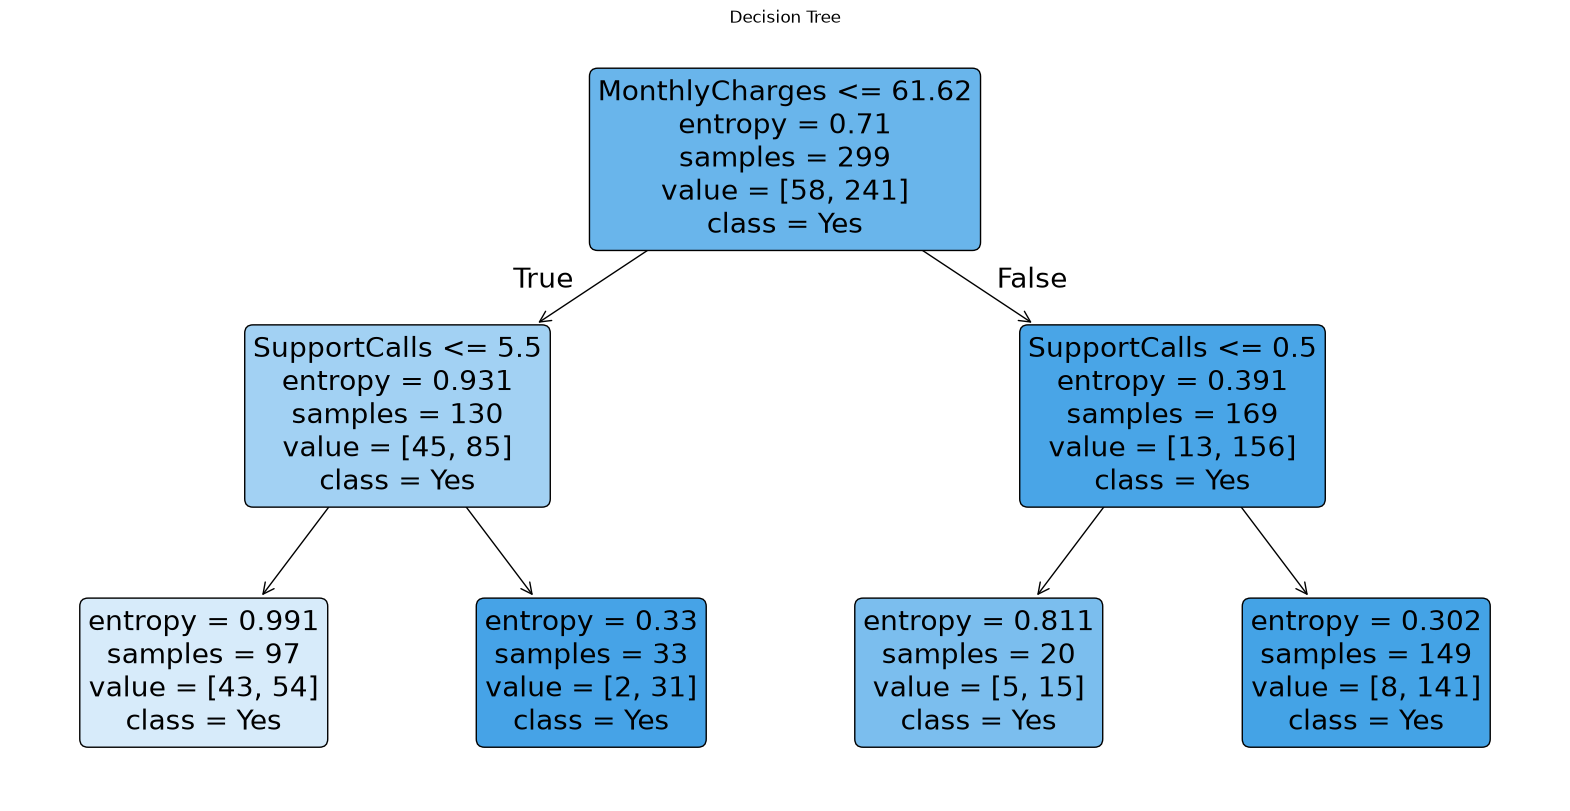

In [234]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

features= [
    "Age",
    "Tenure",
    "MonthlyCharges",
    "SupportCalls",
    "ContractType",
    "InternetService",
    "PaymentMethod"
]

plt.figure(figsize=(20, 10))

plot_tree(
    churntree,
    feature_names = features,
    class_names = ["No", "Yes"],
    filled=True,
    rounded=True
)

plt.title("Decision Tree")
plt.show()

## 12. Confusion Matrix
The Confusion Matrix is used to analyze the model's classification performance. It shows the number of correct and incorrect predictions for each class.

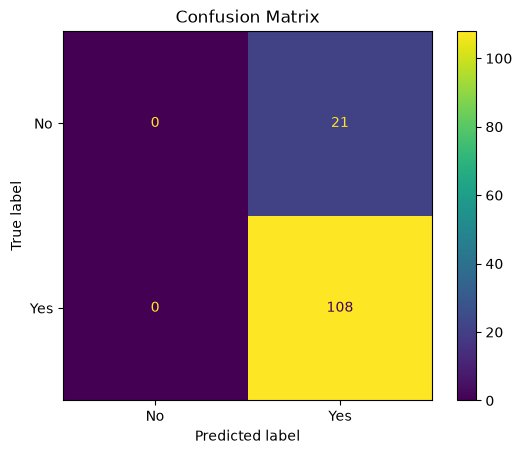

In [227]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, pred_tree)

plt.title("Confusion Matrix")
plt.show()

## 13. Conclusion

In this project, a Decision Tree Classifier was used to predict customer churn.

The dataset was cleaned and categorical features were converted into numerical values before training the model. The model was then evaluated on unseen test data and its behavior was analyzed using different visualizations.

Feature importance was also examined to understand which features contributed most to the model's decisions.
